# XGBoost — Looking Inside the Training Process

This notebook trains an XGBoost classifier and then pulls back the curtain on:
1. The loss shrinking round-by-round as trees are added
2. The actual structure of individual trees
3. Which features drove the predictions, and how much
4. A tiny hand-built boosting loop (no XGBoost) to build intuition for the core idea

Dataset: scikit-learn's built-in breast cancer dataset (binary classification).

## 1. Imports & Data

In [1]:
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

%matplotlib inline

In [7]:
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=list(feature_names))
dtest = xgb.DMatrix(X_test, label=y_test, feature_names=list(feature_names))

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (455, 30)
Test shape: (114, 30)


## 2. Train while watching the loss shrink

`verbose_eval=True` prints the loss after every boosting round.
`evals_result` captures that history so we can plot it afterward.

In [12]:
params = {
    "objective": "binary:logistic",
    "max_depth": 3,        # kept shallow so trees are easy to read later
    "eta": 0.3,
    "eval_metric": "logloss",
}

evals_result = {}
watchlist = [(dtrain, "train"), (dtest, "eval")]

bst = xgb.train(
    params,
    dtrain,
    num_boost_round=20,          # only 20 trees, kept small on purpose
    evals=watchlist,
    evals_result=evals_result,
    verbose_eval=True,           # <-- prints loss after every single round
)

[0]	train-logloss:0.43964	eval-logloss:0.46077
[1]	train-logloss:0.31995	eval-logloss:0.34380
[2]	train-logloss:0.24370	eval-logloss:0.27777
[3]	train-logloss:0.19187	eval-logloss:0.22391
[4]	train-logloss:0.15035	eval-logloss:0.18881
[1]	train-logloss:0.31995	eval-logloss:0.34380
[2]	train-logloss:0.24370	eval-logloss:0.27777
[3]	train-logloss:0.19187	eval-logloss:0.22391
[4]	train-logloss:0.15035	eval-logloss:0.18881
[5]	train-logloss:0.12083	eval-logloss:0.15820
[6]	train-logloss:0.10042	eval-logloss:0.14659
[7]	train-logloss:0.08468	eval-logloss:0.13766
[8]	train-logloss:0.07150	eval-logloss:0.12888
[9]	train-logloss:0.05992	eval-logloss:0.12825
[10]	train-logloss:0.05179	eval-logloss:0.12379
[11]	train-logloss:0.04580	eval-logloss:0.12394
[12]	train-logloss:0.04086	eval-logloss:0.11889
[13]	train-logloss:0.03652	eval-logloss:0.11888
[14]	train-logloss:0.03281	eval-logloss:0.11786
[15]	train-logloss:0.02935	eval-logloss:0.11565
[16]	train-logloss:0.02698	eval-logloss:0.11321
[17]	t

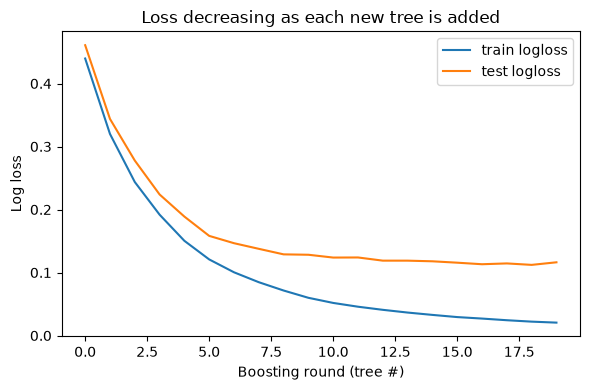

In [16]:
plt.figure(figsize=(6, 4))
plt.plot(evals_result["train"]["logloss"], label="train logloss")
plt.plot(evals_result["eval"]["logloss"], label="test logloss")
plt.xlabel("Boosting round (tree #)")
plt.ylabel("Log loss")
plt.title("Loss decreasing as each new tree is added")
plt.legend()
plt.tight_layout()
plt.show()

## 3. What does an actual tree look like?

Each split shows: the feature, the threshold, `gain` (how much that split reduced loss —
higher means more useful), and `cover` (how many training samples passed through the node).

In [19]:
tree_dump = bst.get_dump(with_stats=True)
print(f"Total trees built: {len(tree_dump)}\n")
print(tree_dump[0])  # raw text structure of the first tree

Total trees built: 20

0:[mean concave points<0.0518199988] yes=1,no=2,missing=2,gain=308.09552,cover=106.228569
	1:[worst radius<16.8199997] yes=3,no=4,missing=4,gain=22.6990814,cover=65.8383636
		3:[radius error<0.536599994] yes=7,no=8,missing=8,gain=3.06655884,cover=61.4024467
			7:leaf=0.454781175,cover=60.2350998
			8:leaf=-0.0197740272,cover=1.16734695
		4:[mean texture<15.71] yes=9,no=10,missing=10,gain=8.64759636,cover=4.43591833
			9:leaf=0.278476715,cover=1.40081632
			10:leaf=-0.458830714,cover=3.03510189
	2:[worst concave points<0.146599993] yes=5,no=6,missing=6,gain=27.6585541,cover=40.3902016
		5:[worst perimeter<115] yes=11,no=12,missing=12,gain=17.6390018,cover=8.17142868
			11:leaf=0.203937724,cover=5.13632631
			12:leaf=-0.607525885,cover=3.03510189
		6:[concavity error<0.102700002] yes=13,no=14,missing=14,gain=2.47364807,cover=32.2187729
			13:leaf=-0.782492518,cover=31.0514278
			14:leaf=-0.158192113,cover=1.16734695



/Users/ganesh/ganku/code/Uptor-AI-ML/Uptor-MohanSivaraman/.venv/lib/python3.12/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` instead. 
  warnings.warn(


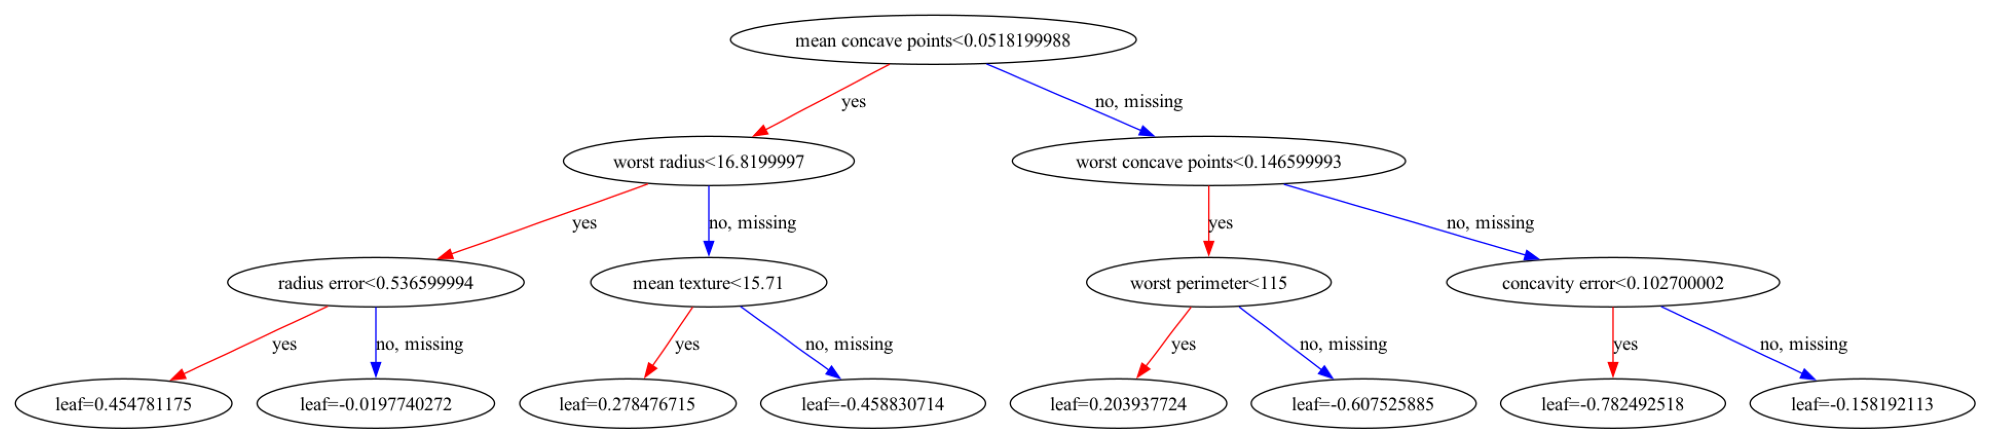

In [22]:
# Visual plot of the first tree (needs graphviz installed: pip install graphviz
# and the graphviz system binary)
fig, ax = plt.subplots(figsize=(20, 10))
xgb.plot_tree(bst, num_trees=0, ax=ax)
plt.tight_layout()
plt.show()

## 4. Which features actually mattered?

Three ways to measure importance:
- **weight** — how many times a feature was used to split
- **gain** — average improvement in accuracy from splits on that feature (usually most meaningful)
- **cover** — average number of samples affected by splits on that feature

In [27]:
for kind in ["weight", "gain", "cover"]:
    scores = bst.get_score(importance_type=kind)
    top5 = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:5]
    print(f"Top 5 by '{kind}':")
    for feat, val in top5:
        print(f"  {feat:25s} {val:.2f}")
    print()

Top 5 by 'weight':
  worst texture             15.00
  mean texture              12.00
  worst concave points      11.00
  worst area                10.00
  mean concave points       7.00

Top 5 by 'gain':
  mean concave points       75.18
  worst concave points      18.91
  worst perimeter           18.33
  worst radius              10.64
  worst concavity           6.45

Top 5 by 'cover':
  radius error              46.17
  mean concave points       44.43
  perimeter error           42.69
  worst radius              34.45
  worst perimeter           29.43



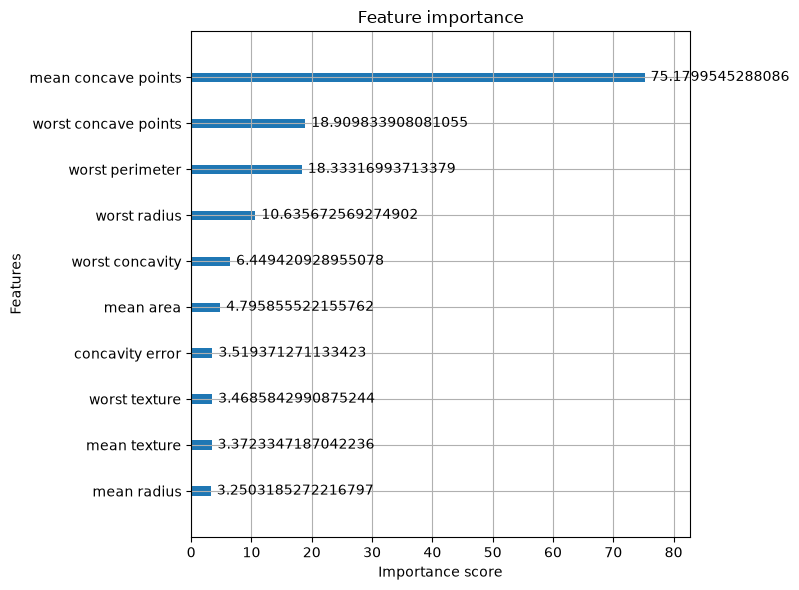

In [31]:
fig, ax = plt.subplots(figsize=(8, 6))
xgb.plot_importance(bst, importance_type="gain", ax=ax, max_num_features=10)
plt.tight_layout()
plt.show()

## 5. Final accuracy check

In [34]:
y_pred = [1 if p > 0.5 else 0 for p in bst.predict(dtest)]
print(f"Final test accuracy: {accuracy_score(y_test, y_pred):.4f}")

Final test accuracy: 0.9561


## 6. Bonus: boosting "by hand" on 5 toy numbers

This strips away all the tree machinery and shows the core boosting idea with plain numbers:
start with a guess (the mean), compute the residual (error), have the next "tree" try to predict
that residual, then add it in (scaled by the learning rate). Repeat.

That's exactly what the 20 real trees above were doing — just with actual decision splits
instead of predicting the residual directly.

In [36]:
y_true = np.array([10, 20, 30, 40, 50], dtype=float)
prediction = np.full_like(y_true, y_true.mean())  # start: predict the average
learning_rate = 0.5

print(f"Start prediction (just the mean): {prediction}")

for round_num in range(1, 4):
    residual = y_true - prediction          # what we still got wrong
    tree_prediction = residual              # simplified "tree": predict residual directly
    prediction = prediction + learning_rate * tree_prediction
    print(f"\nRound {round_num}:")
    print(f"  residual (errors so far): {residual}")
    print(f"  updated prediction:       {prediction}")

print(f"\nTrue values were:            {y_true}")

Start prediction (just the mean): [30. 30. 30. 30. 30.]

Round 1:
  residual (errors so far): [-20. -10.   0.  10.  20.]
  updated prediction:       [20. 25. 30. 35. 40.]

Round 2:
  residual (errors so far): [-10.  -5.   0.   5.  10.]
  updated prediction:       [15.  22.5 30.  37.5 45. ]

Round 3:
  residual (errors so far): [-5.  -2.5  0.   2.5  5. ]
  updated prediction:       [12.5  21.25 30.   38.75 47.5 ]

True values were:            [10. 20. 30. 40. 50.]
